In [7]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [8]:
np.random.seed(42)
n = 140
x = np.linspace(-3 , 3 , n)
y_true = np.sin(x) + 0.3 * x + 0.10 * np.cos(3 * x)
y = y_true + np.random.normal(scale = 0.30 , size = n)
X = x.reshape(-1 , 1)
X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size = 0.40 , random_state = 42
)
x_grid = np.linspace(X.min() , X.max() , 500).reshape(-1 , 1)
y_true_grid = np.sin(x_grid.ravel()) + 0.3 * x_grid.ravel() + 0.10 * np.cos(3 * x_grid.ravel())

In [9]:
def build_spline_model(n_knots , degree = 3):
    return make_pipeline(SplineTransformer(
        n_knots = n_knots , degree = degree , include_bias = False
        ) , LinearRegression()
    )

def fit_predict_score(n_knots):
    model = build_spline_model(n_knots = n_knots , degree = 3)
    _ = model.fit(X_train , y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_grid_pred = model.predict(x_grid)
    train_mse = mean_squared_error(y_train , y_train_pred)
    test_mse = mean_squared_error(y_test , y_test_pred)
    return model , y_grid_pred , train_mse , test_mse

In [10]:
representative_knots = {"Too rigid": 4 , "Good balance": 9 , "Too flexible": 18}
hero_predictions = {}
summary_rows = []
for label , k in representative_knots.items():
    _ , y_grid_pred , train_mse , test_mse = fit_predict_score(k)
    hero_predictions[label] = y_grid_pred
    summary_rows.append({"label": label , "knots": k ,
                         "train_mse": train_mse , "test_mse": test_mse})

knot_grid = list(range(3 , 19))
train_curve = []
test_curve = []
for k in knot_grid:
    _ , _ , train_mse , test_mse = fit_predict_score(k)
    train_curve.append(train_mse)
    test_curve.append(test_mse)

best_idx = int(np.argmin(test_curve))
best_k = knot_grid[best_idx]
best_test_mse = test_curve[best_idx]

<Figure size 1000x580 with 0 Axes>

Text(0.5, 1.0, 'Spline Regression: Controlled Flexibility')

Text(0.5, 0, 'X')

Text(0, 0.5, 'y')

Text(0.02, 0.03, 'Few knots = too rigid\nModerate knots = smoother balance\nToo many knots = more local wiggles')

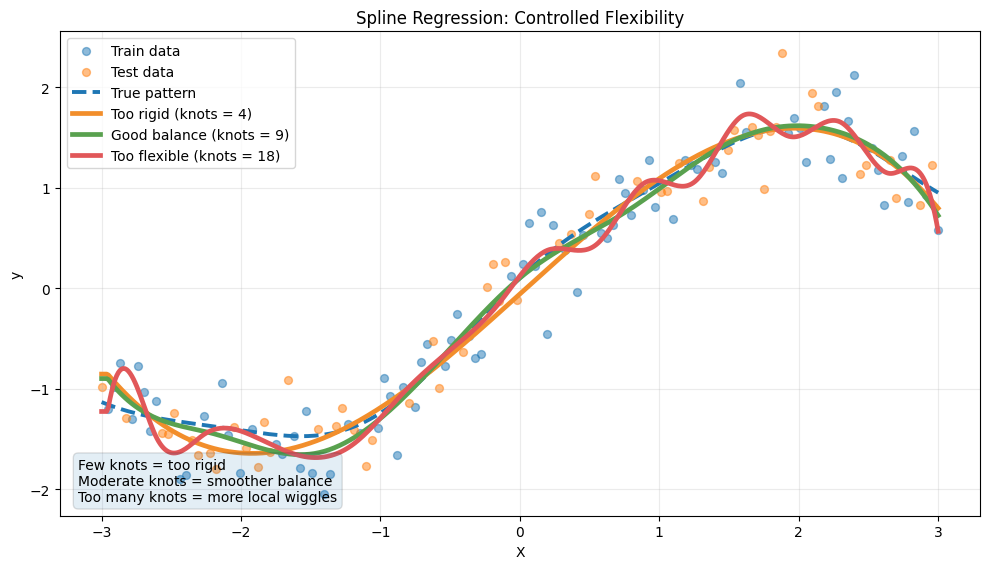

In [11]:
plt.figure(figsize = (10 , 5.8))
plt.scatter(X_train , y_train , alpha = 0.50 , s = 32 , label = "Train data")
plt.scatter(X_test , y_test , alpha = 0.50 , s = 32 , label = "Test data")
plt.plot(x_grid , y_true_grid , linestyle = "--" , linewidth = 2.8 , label = "True pattern")

colors = {"Too rigid": "#f28e2b" , "Good balance": "#59a14f" , "Too flexible": "#e15759"}
for label in representative_knots:
    plt.plot(x_grid , hero_predictions[label] , linewidth = 3.4 , color = colors[label] ,
             label = f"{label} (knots = {representative_knots[label]})")

plt.title("Spline Regression: Controlled Flexibility")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(alpha = 0.25)
plt.legend(loc = "upper left")

plt.text(0.02 , 0.03 ,
    "Few knots = too rigid\nModerate knots = smoother balance\nToo many knots = more local wiggles" ,
    transform = plt.gca().transAxes , bbox = dict(boxstyle = "round , pad = 0.35" , alpha = 0.12))
plt.tight_layout()
plt.show()

<Figure size 880x520 with 0 Axes>

Text(0.5, 1.0, 'Choosing Knot Count: Too Rigid vs Too Flexible')

Text(0.5, 0, 'Number of knots')

Text(0, 0.5, 'MSE')

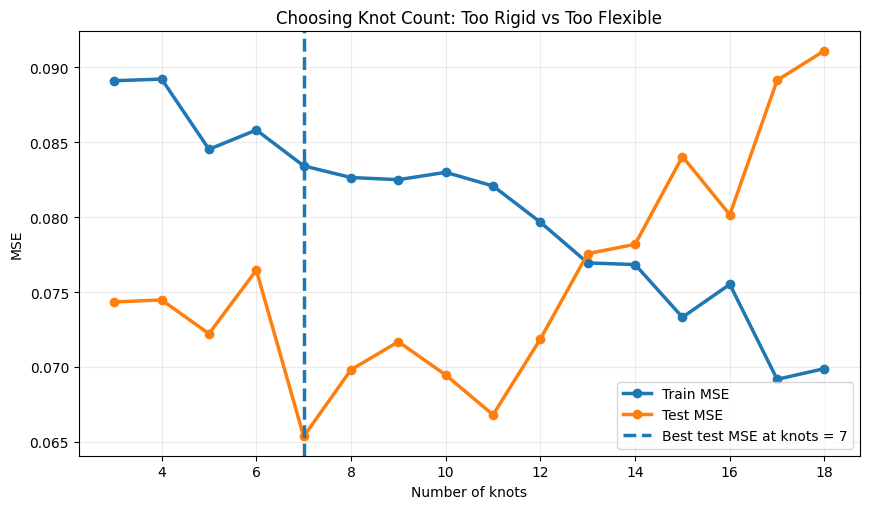

In [12]:
plt.figure(figsize = (8.8 , 5.2))
plt.plot(knot_grid , train_curve , marker = "o" , linewidth = 2.5 , label = "Train MSE")
plt.plot(knot_grid , test_curve , marker = "o" , linewidth = 2.5 , label = "Test MSE")
plt.axvline(best_k , linestyle = "--" , linewidth = 2.5 ,
            label = f"Best test MSE at knots = {best_k}")
plt.title("Choosing Knot Count: Too Rigid vs Too Flexible")
plt.xlabel("Number of knots")
plt.ylabel("MSE")
plt.grid(alpha = 0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
print("======================== Day 17 Summary ========================")
for row in summary_rows:
    print(f"{row['label']:13s} | knots = {row['knots']:2d} | "
    f"train MSE = {row['train_mse']:.3f} | "
    f"test MSE = {row['test_mse']:.3f}")
print()
print(f"Best knot count by test MSE: {best_k}")
print(f"Best test MSE: {best_test_mse:.3f}")
print("\nKey takeaway:")
print("Splines fit nonlinear structure locally.")
print("Too few knots underfit; too many knots can become overly flexible.")
print("A moderate knot count usually gives the best balance.")

======================== Day 17 Summary ========================
Too rigid     | knots =  4 | train MSE = 0.089 | test MSE = 0.074
Good balance  | knots =  9 | train MSE = 0.083 | test MSE = 0.072
Too flexible  | knots = 18 | train MSE = 0.070 | test MSE = 0.091

Best knot count by test MSE: 7
Best test MSE: 0.065

Key takeaway:
Splines fit nonlinear structure locally.
Too few knots underfit; too many knots can become overly flexible.
A moderate knot count usually gives the best balance.
